# TIG Shapley Value Simulation

This notebook implements a simulation of reward allocation using Shapley values for four key actors in the TIG ecosystem. The model uses a Cobb-Douglas production function to calculate coalition values.

## 1. User Inputs

Configure the simulation parameters below:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import scipy as sp
sys.path.append('../')
from tig_shapely import (
    ACTORS,
    compute_hmc_shapley_values,
    maximize_and_quantify_uncertainty
)

# Set style for publication-ready plots
# plt.style.use('seaborn')
sns.set_context("paper", font_scale=1.5)
plt.rcParams['figure.figsize'] = [7, 4]
# plt.rcParams['font.family'] = 'serif'
# plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Simulation settings
n_samples = 200

# Labor contribution priors
alpha_labor_priors = {
    "B": (1.0, 0.2),   # Benchmarkers
    "CI": (0.2, 0.1),  # Code Innovators
    "AI": (2.4, 0.2),  # Algorithm Innovators
    "CM": (0.4, 0.1)   # Challenge Maintainers
}

# Capital contribution priors
alpha_capital_priors = {
    "B": (1.0, 0.2),
    "CI": (0.2, 0.1),
    "AI": (2.4, 0.2),
    "CM": (0.4, 0.1)
}

# Bonus factors (gamma) priors
gamma_priors = {
    "AI": (1.0, 0.2),  # Algorithm Innovators bonus
    "CM": (0.5, 0.1)   # Challenge Maintainers bonus
}

# Production function parameters
delta_prior = (0.6, 0.1)  # Labor elasticity
kappa_prior = (0.4, 0.1)  # Capital elasticity

## 2. Run Simulation

Run the Hamiltonian Monte Carlo sampling and optimization:

In [2]:
print("Running Hamiltonian Monte Carlo sampling for Forward UQ...")
uq_shapley_values = compute_hmc_shapley_values(
    alpha_labor_priors, alpha_capital_priors, gamma_priors, 
    delta_prior, kappa_prior, n_samples
)

print("Optimizing parameters to maximize total value...")
optimal_params, optimal_shapley, shapley_uncertainty = maximize_and_quantify_uncertainty(
    alpha_labor_priors, alpha_capital_priors, gamma_priors, 
    delta_prior, kappa_prior, n_samples
)

Running Hamiltonian Monte Carlo sampling for Forward UQ...


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [alpha_labor_B, alpha_labor_CI, alpha_labor_AI, alpha_labor_CM, alpha_capital_B, alpha_capital_CI, alpha_capital_AI, alpha_capital_CM, gamma_AI, gamma_CM, delta, kappa]


Output()

Sampling 2 chains for 1_000 tune and 200 draw iterations (2_000 + 400 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


Optimizing parameters to maximize total value...


Output()

/home/kiran/code/cel/streamlit/tig_shapely/notebooks/../tig_shapely/core/simulation.py:272: FutureWarning: The `start` kwarg was renamed to `initvals` and can now do more. Please check the docstring.
  trace = pm.sample(n_samples, tune=1000, chains=2, cores=1,
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [alpha_labor_B, alpha_labor_CI, alpha_labor_AI, alpha_labor_CM, alpha_capital_B, alpha_capital_CI, alpha_capital_AI, alpha_capital_CM, gamma_AI, gamma_CM, delta, kappa]


Output()

Sampling 2 chains for 1_000 tune and 200 draw iterations (2_000 + 400 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


## 3. Visualize Results

### 3.1 Forward UQ Results

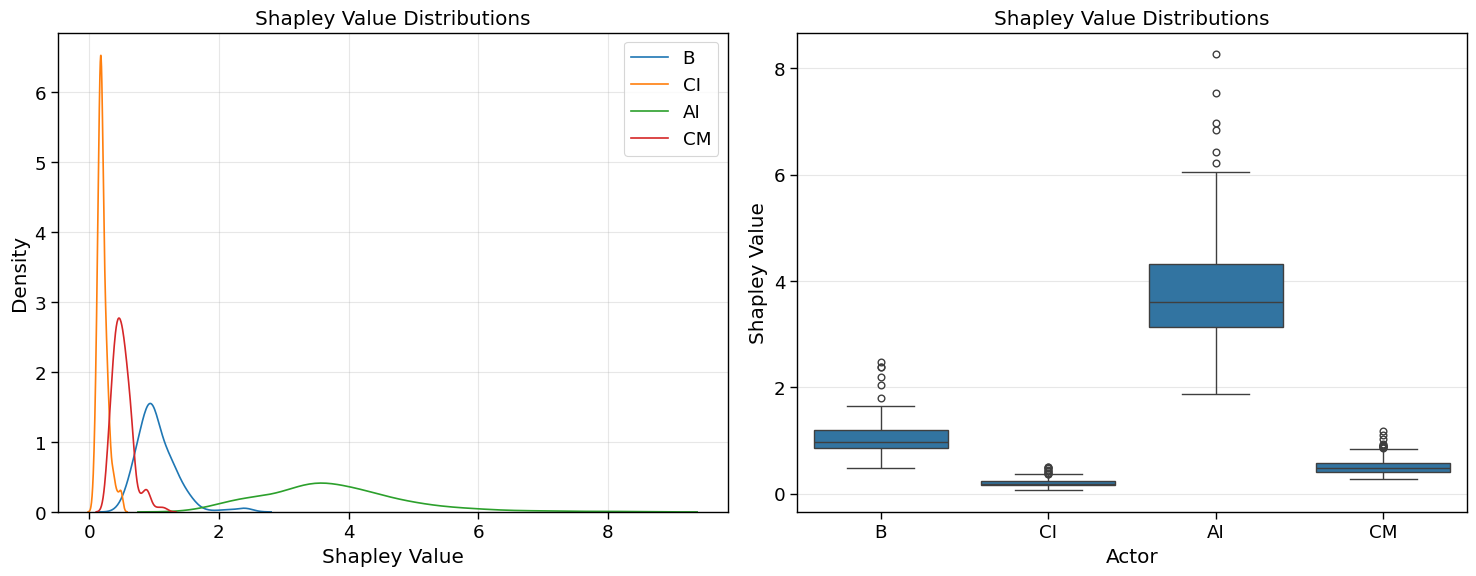


Summary Statistics:


,Actor,Mean,Std,25th Percentile,Median,75th Percentile
0,B,1.042470,0.316842,0.852985,0.979266,1.191739
1,CI,0.206784,0.079887,0.156241,0.187144,0.240483
2,AI,3.766474,1.072036,3.140154,3.612080,4.314732
3,CM,0.513573,0.156649,0.400477,0.489008,0.581435


In [3]:
# Create a figure with subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Shapley Value Distributions
for actor in ACTORS:
    sns.kdeplot(data=uq_shapley_values[actor], label=actor, ax=ax1)
ax1.set_title('Shapley Value Distributions')
ax1.set_xlabel('Shapley Value')
ax1.set_ylabel('Density')
ax1.legend()

# Plot 2: Boxplot
data = []
for actor in ACTORS:
    for val in uq_shapley_values[actor]:
        data.append({'Actor': actor, 'Shapley Value': val})
df = pd.DataFrame(data)
sns.boxplot(data=df, x='Actor', y='Shapley Value', ax=ax2)
ax2.set_title('Shapley Value Distributions')

plt.tight_layout()
plt.show()

# Create summary table
summary_data = []
for actor in ACTORS:
    values = uq_shapley_values[actor]
    summary_data.append({
        'Actor': actor,
        'Mean': np.mean(values),
        'Std': np.std(values),
        '25th Percentile': np.percentile(values, 25),
        'Median': np.median(values),
        '75th Percentile': np.percentile(values, 75)
    })
summary_df = pd.DataFrame(summary_data)
print("\nSummary Statistics:")
display(summary_df)

### 3.2 Optimization Results

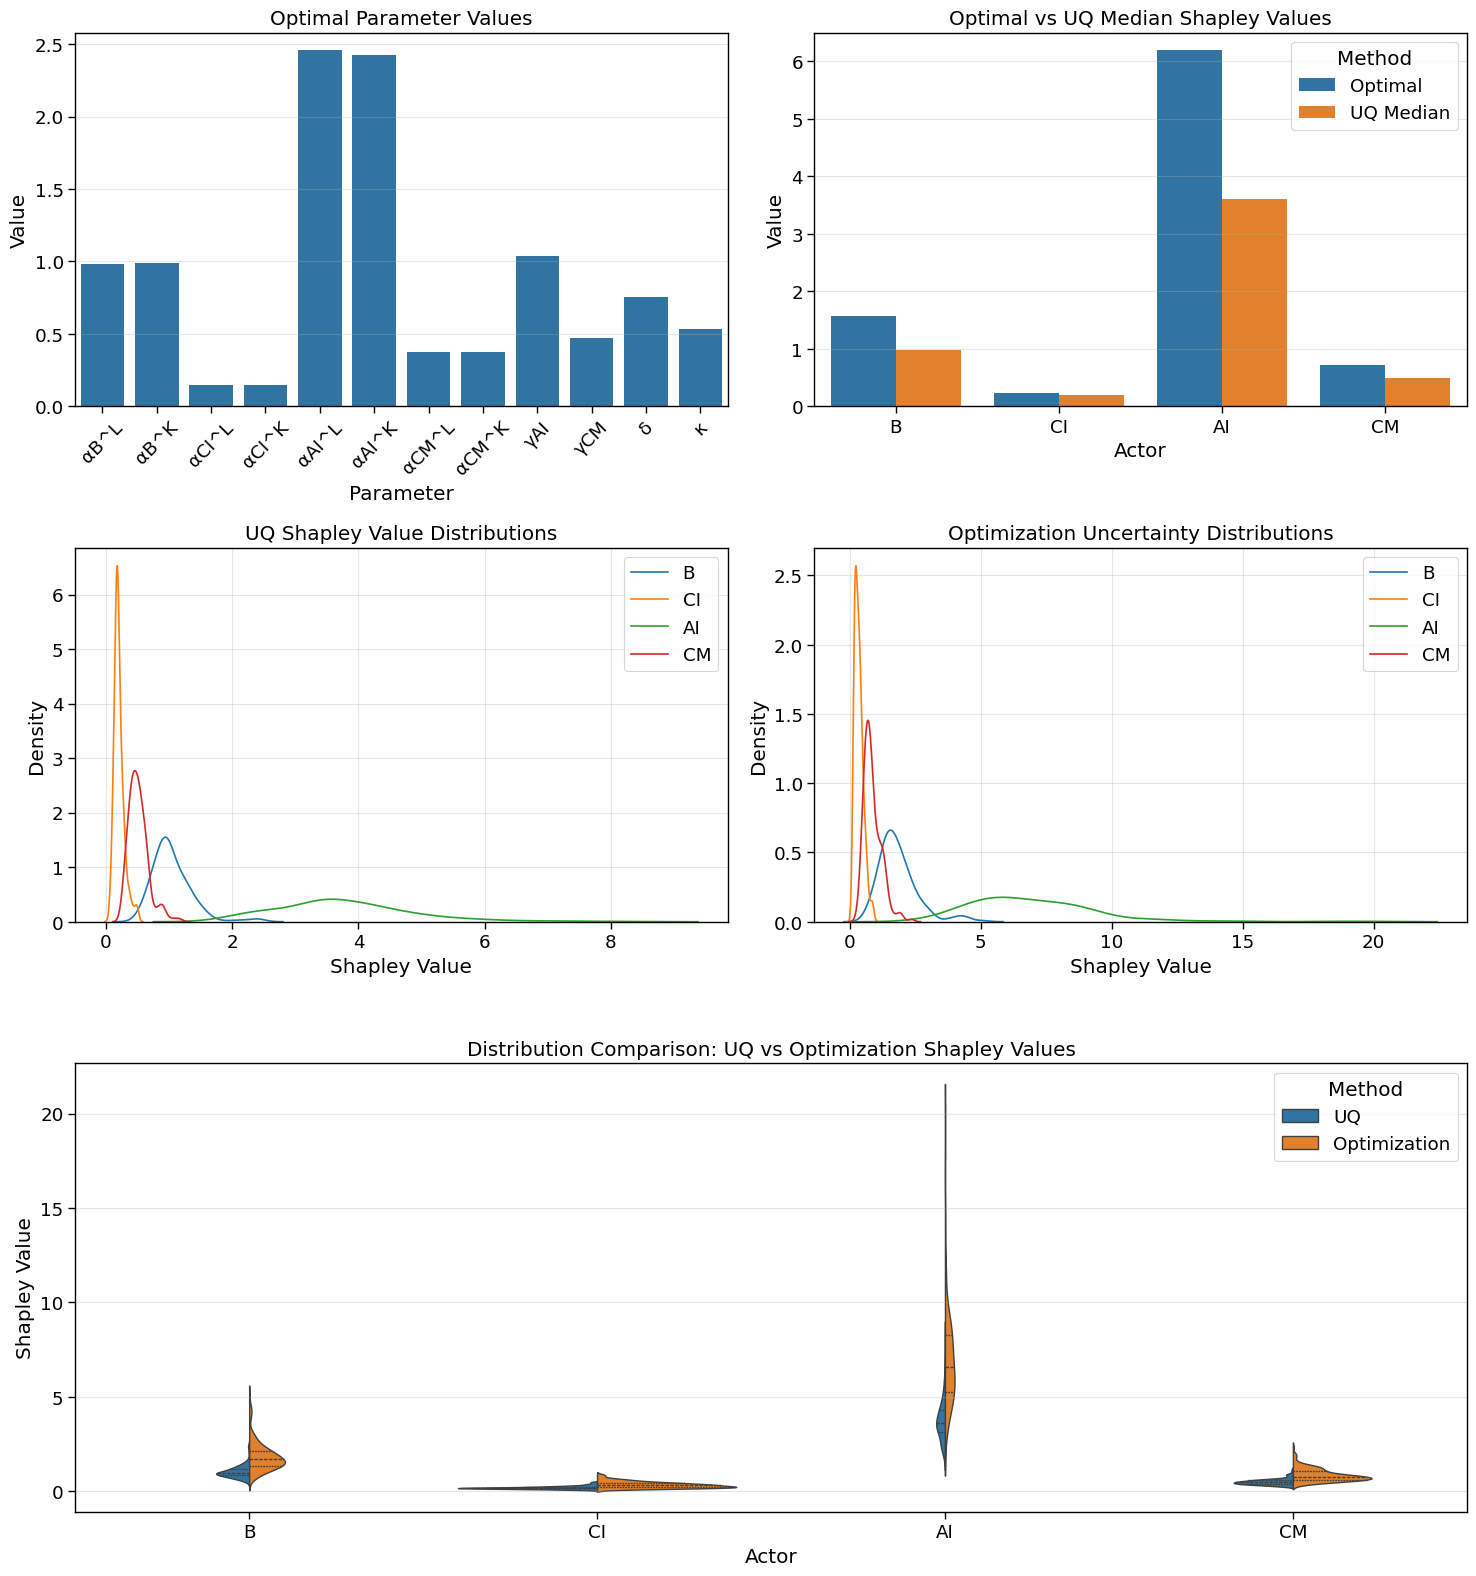


Optimal Parameters:


,Parameter,Value
0,αB^L,0.979154
1,αB^K,0.986915
2,αCI^L,0.147831
3,αCI^K,0.148825
4,αAI^L,2.457596
5,αAI^K,2.422620
6,αCM^L,0.377551
7,αCM^K,0.375150
8,γAI,1.040596
9,γCM,0.474703



Summary Statistics for UQ Shapley Values:


,Actor,Mean,Std,25th Percentile,Median,75th Percentile
0,B,1.042470,0.316842,0.852985,0.979266,1.191739
1,CI,0.206784,0.079887,0.156241,0.187144,0.240483
2,AI,3.766474,1.072036,3.140154,3.612080,4.314732
3,CM,0.513573,0.156649,0.400477,0.489008,0.581435



Summary Statistics for Optimization Uncertainty:


,Actor,Mean,Std,25th Percentile,Median,75th Percentile
0,B,1.847610,0.752456,1.366798,1.713189,2.142356
1,CI,0.353259,0.163814,0.224508,0.322366,0.439436
2,AI,6.938372,2.466167,5.286324,6.569806,8.261136
3,CM,0.874293,0.335254,0.623162,0.790188,1.068300


In [4]:
# Create a figure with subplots for all visualizations
# fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
fig = plt.figure(figsize=(15, 16))
gs = fig.add_gridspec(3, 2, height_ratios=[1, 1, 1.2])
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])
ax5 = fig.add_subplot(gs[2, :])  # New subplot spanning full width

# Plot 1: Optimal Parameter Values (top left)
params_data = []
for actor in ACTORS:
    params_data.append({
        'Parameter': f'α{actor}^L',
        'Value': float(optimal_params['alpha_labor'][actor])
    })
    params_data.append({
        'Parameter': f'α{actor}^K', 
        'Value': float(optimal_params['alpha_capital'][actor])
    })
for actor in ['AI', 'CM']:
    params_data.append({
        'Parameter': f'γ{actor}',
        'Value': float(optimal_params['gammas'][actor])
    })
params_data.append({'Parameter': 'δ', 'Value': float(optimal_params['delta'])})
params_data.append({'Parameter': 'κ', 'Value': float(optimal_params['kappa'])})
params_df = pd.DataFrame(params_data)

# Convert Parameter column to category type with specific order
params_df['Parameter'] = pd.Categorical(params_df['Parameter'], 
                                      categories=params_df['Parameter'].unique(),
                                      ordered=True)

sns.barplot(data=params_df, x='Parameter', y='Value', ax=ax1)
ax1.set_title('Optimal Parameter Values')
ax1.tick_params(axis='x', rotation=45)

# Plot 2: Optimal vs UQ Median Shapley Values (top right)
comparison_data = []
for actor in ACTORS:
    comparison_data.append({
        'Actor': actor,
        'Method': 'Optimal',
        'Value': optimal_shapley[actor]
    })
    comparison_data.append({
        'Actor': actor,
        'Method': 'UQ Median',
        'Value': np.median(uq_shapley_values[actor])
    })
comparison_df = pd.DataFrame(comparison_data)

sns.barplot(data=comparison_df, x='Actor', y='Value', hue='Method', ax=ax2)
ax2.set_title('Optimal vs UQ Median Shapley Values')

# Plot 3: Distribution of Shapley Values from UQ (bottom left)
for actor in ACTORS:
    sns.kdeplot(data=uq_shapley_values[actor], label=actor, ax=ax3)
ax3.set_title('UQ Shapley Value Distributions')
ax3.set_xlabel('Shapley Value')
ax3.set_ylabel('Density')
ax3.legend()

# Plot 4: Distribution of Shapley Values around Optimum (bottom right)
for actor in ACTORS:
    sns.kdeplot(data=shapley_uncertainty[actor], label=actor, ax=ax4)
ax4.set_title('Optimization Uncertainty Distributions')
ax4.set_xlabel('Shapley Value')
ax4.set_ylabel('Density')
ax4.legend()

# Plot 5: Violin Plot Comparison (new bottom plot)
violin_data = []
for actor in ACTORS:
    # Add UQ Shapley values
    for value in uq_shapley_values[actor]:
        violin_data.append({
            'Actor': actor,
            'Method': 'UQ',
            'Value': value
        })
    # Add Optimization Uncertainty values
    for value in shapley_uncertainty[actor]:
        violin_data.append({
            'Actor': actor,
            'Method': 'Optimization',
            'Value': value
        })
violin_df = pd.DataFrame(violin_data)

sns.violinplot(data=violin_df, x='Actor', y='Value', hue='Method', 
              split=True, inner='quartile', ax=ax5)
ax5.set_title('Distribution Comparison: UQ vs Optimization Shapley Values')
ax5.set_xlabel('Actor')
ax5.set_ylabel('Shapley Value')

plt.tight_layout()
plt.show()

# Display summary statistics
print("\nOptimal Parameters:")
display(params_df)

print("\nSummary Statistics for UQ Shapley Values:")
summary_data = []
for actor in ACTORS:
    values = uq_shapley_values[actor]
    summary_data.append({
        'Actor': actor,
        'Mean': np.mean(values),
        'Std': np.std(values),
        '25th Percentile': np.percentile(values, 25),
        'Median': np.median(values),
        '75th Percentile': np.percentile(values, 75)
    })
summary_df = pd.DataFrame(summary_data)
display(summary_df)

print("\nSummary Statistics for Optimization Uncertainty:")
summary_data = []
for actor in ACTORS:
    values = shapley_uncertainty[actor]
    summary_data.append({
        'Actor': actor,
        'Mean': np.mean(values),
        'Std': np.std(values),
        '25th Percentile': np.percentile(values, 25),
        'Median': np.median(values),
        '75th Percentile': np.percentile(values, 75)
    })
summary_df = pd.DataFrame(summary_data)
display(summary_df)

### 3.3 Prior Distributions

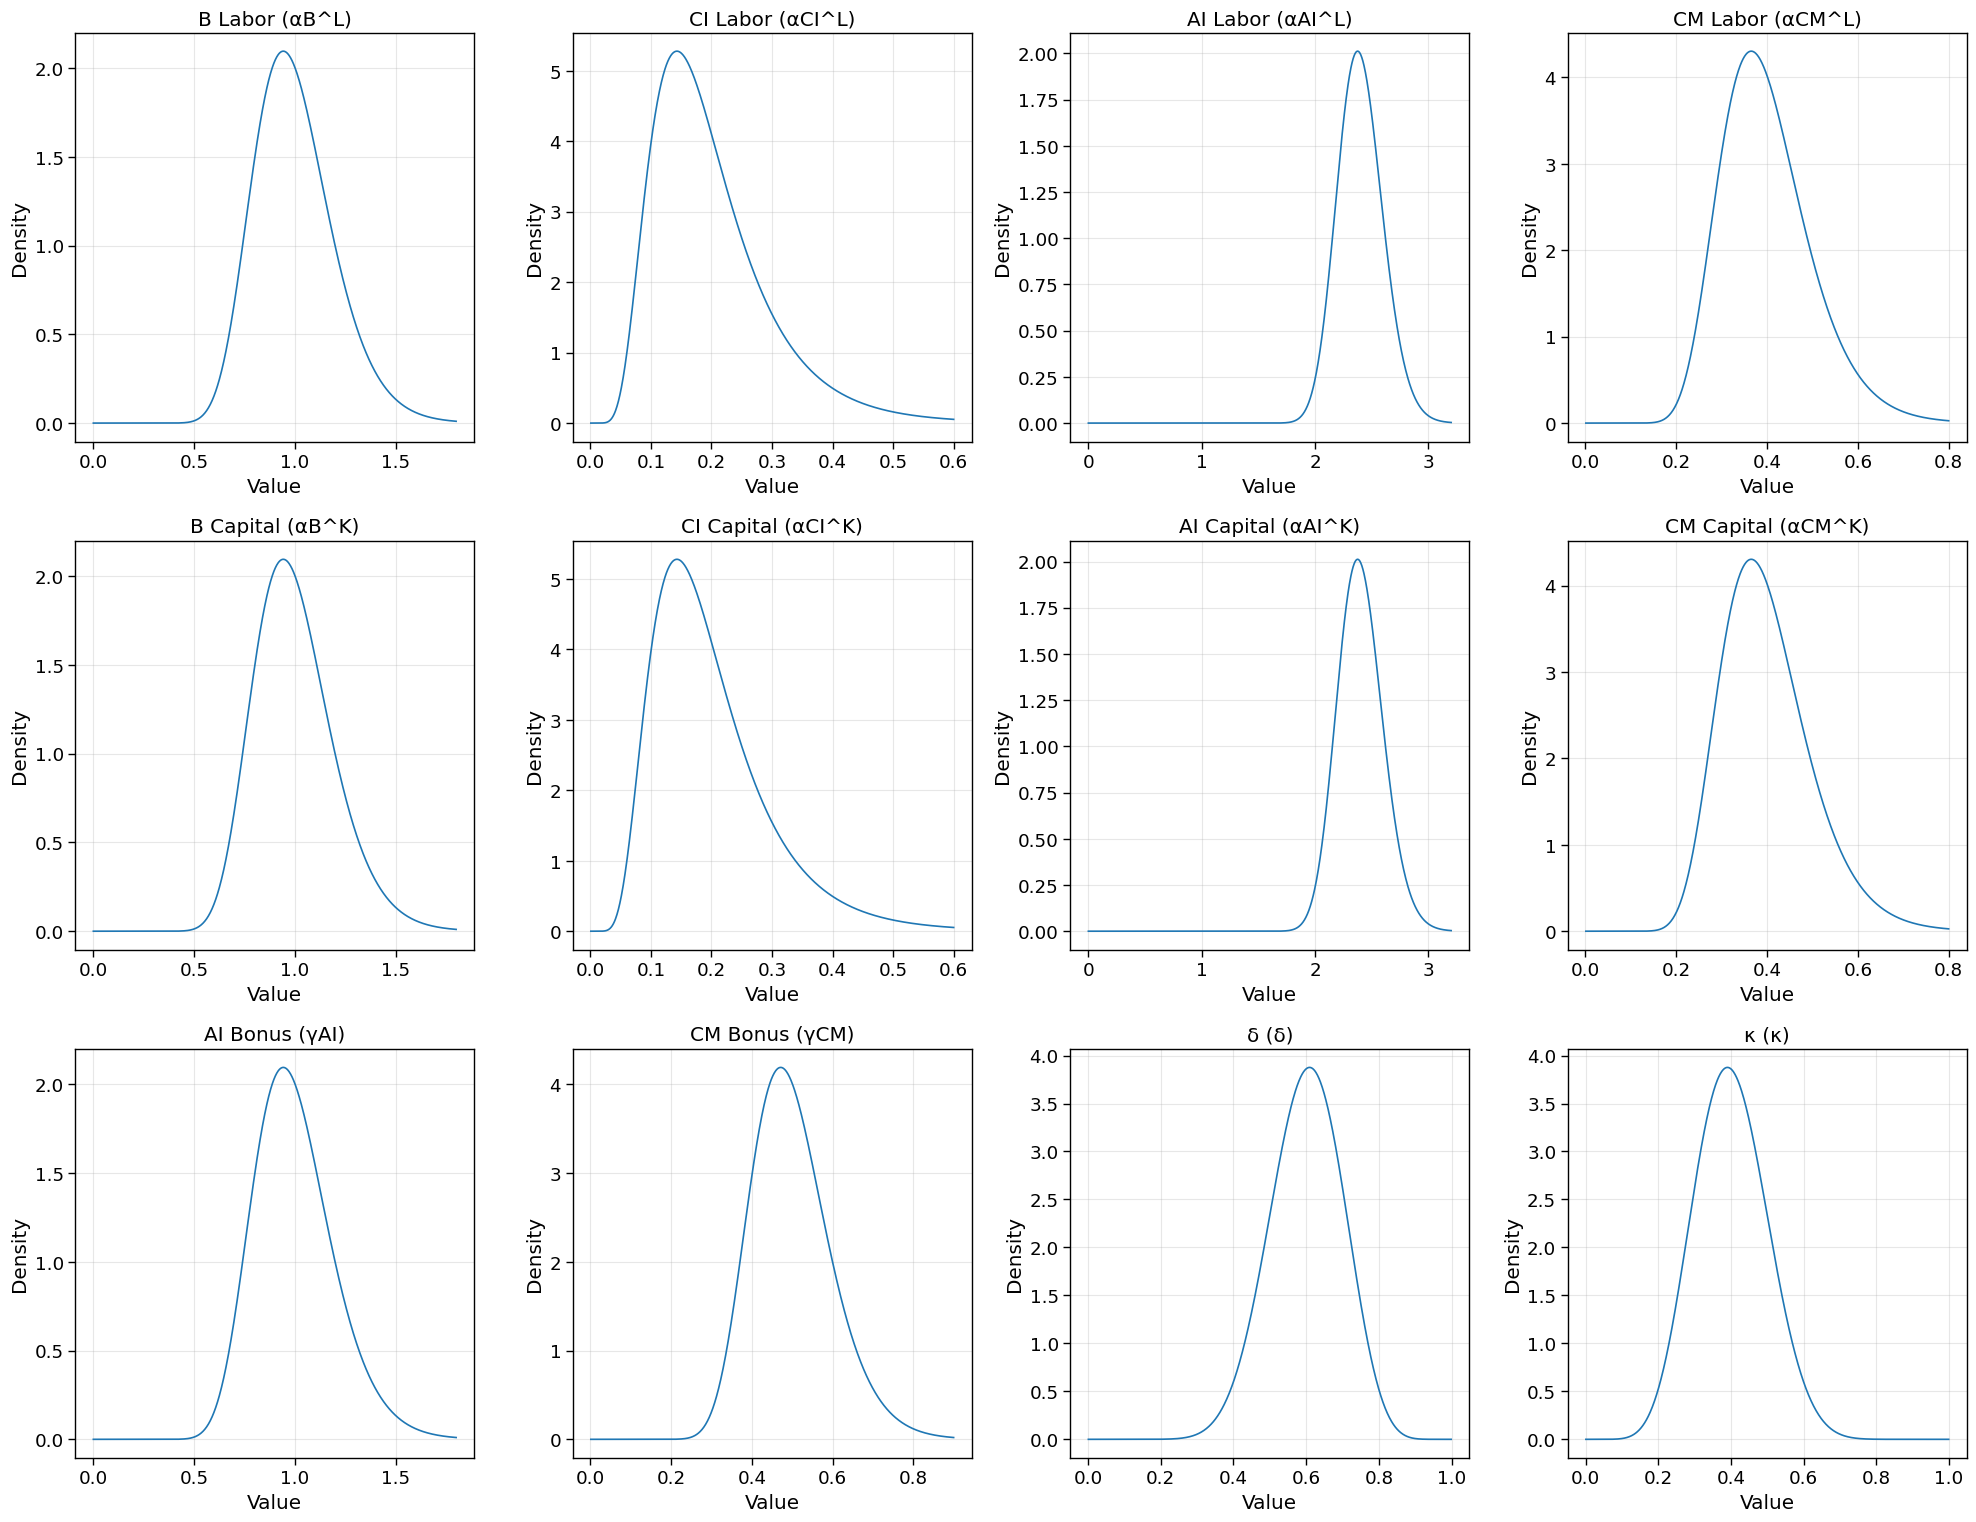

In [5]:
# Create a figure with subplots
fig, axes = plt.subplots(4, 4, figsize=(20, 20))
axes = axes.flatten()

# Plot labor contribution priors
for i, (actor, (mean, std)) in enumerate(alpha_labor_priors.items()):
    x = np.linspace(0.001, mean + 4*std, 1000)
    mu = np.log(mean**2 / np.sqrt(mean**2 + std**2))
    sigma = np.sqrt(np.log(1 + (std**2 / mean**2)))
    pdf = sp.stats.lognorm.pdf(x, s=sigma, scale=np.exp(mu))
    
    axes[i].plot(x, pdf)
    axes[i].set_title(f'{actor} Labor (α{actor}^L)')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')

# Plot capital contribution priors
for i, (actor, (mean, std)) in enumerate(alpha_capital_priors.items()):
    x = np.linspace(0.001, mean + 4*std, 1000)
    mu = np.log(mean**2 / np.sqrt(mean**2 + std**2))
    sigma = np.sqrt(np.log(1 + (std**2 / mean**2)))
    pdf = sp.stats.lognorm.pdf(x, s=sigma, scale=np.exp(mu))
    
    axes[i+4].plot(x, pdf)
    axes[i+4].set_title(f'{actor} Capital (α{actor}^K)')
    axes[i+4].set_xlabel('Value')
    axes[i+4].set_ylabel('Density')

# Plot gamma priors
for i, (actor, (mean, std)) in enumerate(gamma_priors.items()):
    x = np.linspace(0.001, mean + 4*std, 1000)
    mu = np.log(mean**2 / np.sqrt(mean**2 + std**2))
    sigma = np.sqrt(np.log(1 + (std**2 / mean**2)))
    pdf = sp.stats.lognorm.pdf(x, s=sigma, scale=np.exp(mu))
    
    axes[i+8].plot(x, pdf)
    axes[i+8].set_title(f'{actor} Bonus (γ{actor})')
    axes[i+8].set_xlabel('Value')
    axes[i+8].set_ylabel('Density')

# Plot delta and kappa priors (beta distribution)
for i, (name, (mean, std)) in enumerate([('δ', delta_prior), ('κ', kappa_prior)]):
    x = np.linspace(0.001, 0.999, 1000)
    var = std**2
    if var >= mean * (1 - mean):
        var = 0.9 * mean * (1 - mean)
    alpha_param = max(0.01, mean * (mean * (1 - mean) / var - 1))
    beta_param = max(0.01, (1 - mean) * (mean * (1 - mean) / var - 1))
    pdf = sp.stats.beta.pdf(x, alpha_param, beta_param)
    
    axes[i+10].plot(x, pdf)
    axes[i+10].set_title(f'{name} ({name})')
    axes[i+10].set_xlabel('Value')
    axes[i+10].set_ylabel('Density')

# Hide unused subplots
for i in range(12, 16):
    axes[i].set_visible(False)

plt.tight_layout()
plt.savefig('../figures/priors.png')